# Sales Performance Dashboard — Exploratory Data Analysis (EDA)

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the cleaned sales dataset to uncover patterns, trends, and business opportunities.

It includes **20+ visualizations** covering sales performance, profitability, customer behavior, product performance, regional analysis, discount impact, shipping trends, and customer segmentation. Each visualization is accompanied by key business insights and actionable recommendations.

### Analysis Covered

- Sales & Profit Overview
- Category & Sub-Category Performance
- Product Analysis
- Customer Analysis
- Regional & State Performance
- Monthly, Quarterly & Yearly Trends
- Discount & Profitability Analysis
- Shipping Performance
- Correlation Analysis
- Customer Segmentation (RFM, ABC/Pareto & CLV)

## Setup

In [2]:


import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
PALETTE = "crest"

df = pd.read_csv("../data/cleaned/Superstore_Cleaned.csv", parse_dates=["Order Date", "Ship Date"])
IMG = "../images/"
today = df["Order Date"].max() 


def savefig(name: str) -> None:
    plt.tight_layout()
    path = f"{IMG}{name}.png"
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    display(Image(filename=path))


def report(n: int, title: str, insight: str, recommendation: str) -> None:
    print(f"\n[{n}] {title}")
    print(f"  Insight       : {insight}")
    print(f"  Recommendation: {recommendation}")



## Chart 1 — Sales Distribution

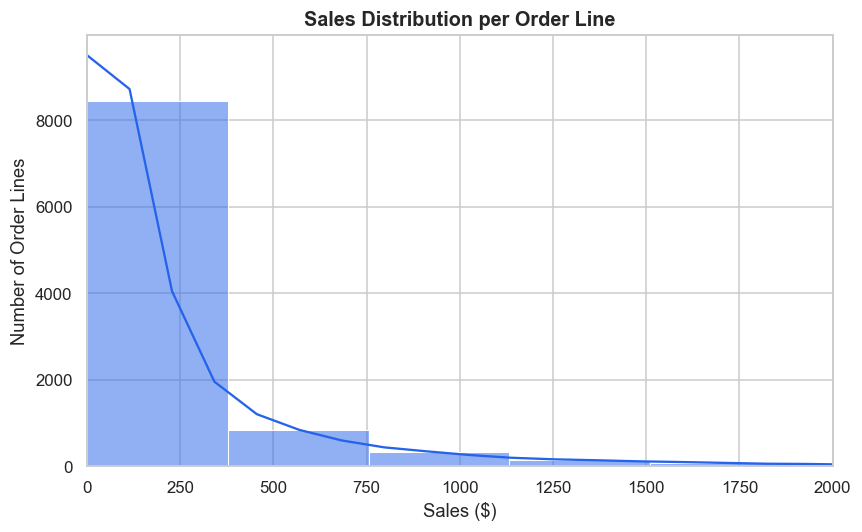


[1] Sales Distribution
  Insight       : Median order-line sales is $54.49 vs. a mean of $229.86 — a right-skewed distribution driven by a small number of large orders.
  Recommendation: Don't use the mean alone for pricing/target-setting conversations; report median alongside mean to avoid overstating what a 'typical' order looks like.


In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], bins=60, kde=True, color="#2563eb")
plt.title("Sales Distribution per Order Line", fontsize=13, fontweight="bold")
plt.xlabel("Sales ($)"); plt.ylabel("Number of Order Lines")
plt.xlim(0, 2000)
savefig("01_sales_distribution")
report(1, "Sales Distribution",
       f"Median order-line sales is ${df['Sales'].median():.2f} vs. a mean of ${df['Sales'].mean():.2f} "
       "— a right-skewed distribution driven by a small number of large orders.",
       "Don't use the mean alone for pricing/target-setting conversations; report median alongside mean "
       "to avoid overstating what a 'typical' order looks like.")

## Chart 2 — Profit Distribution

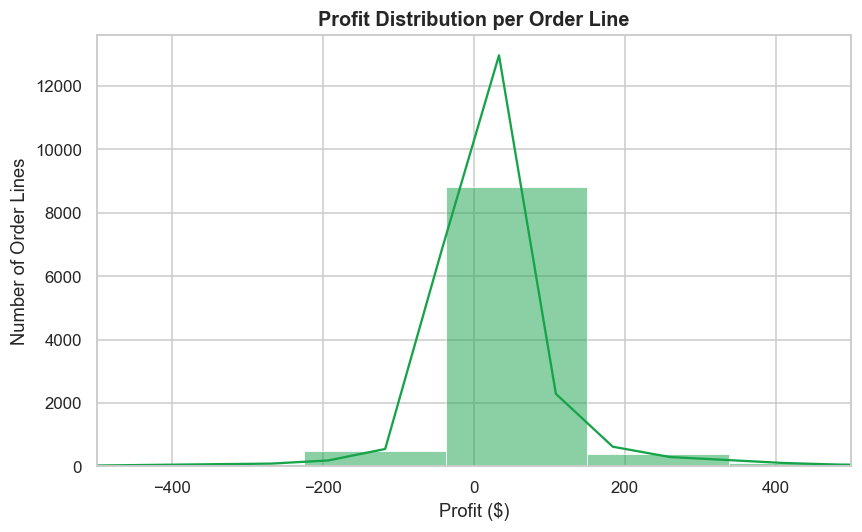


[2] Profit Distribution
  Insight       : 18.7% of all order lines are sold at a loss.
  Recommendation: Flag loss-making order lines at the point of sale (e.g. a discount-approval workflow) rather than discovering them only in quarterly reporting.


In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Profit"], bins=80, kde=True, color="#16a34a")
plt.title("Profit Distribution per Order Line", fontsize=13, fontweight="bold")
plt.xlabel("Profit ($)"); plt.ylabel("Number of Order Lines")
plt.xlim(-500, 500)
savefig("02_profit_distribution")
pct_unprofitable = (df["Profit"] < 0).mean() * 100
report(2, "Profit Distribution",
       f"{pct_unprofitable:.1f}% of all order lines are sold at a loss.",
       "Flag loss-making order lines at the point of sale (e.g. a discount-approval workflow) rather than "
       "discovering them only in quarterly reporting.")

## Chart 3 — Revenue Trend (Explicit Monthly Revenue Line)

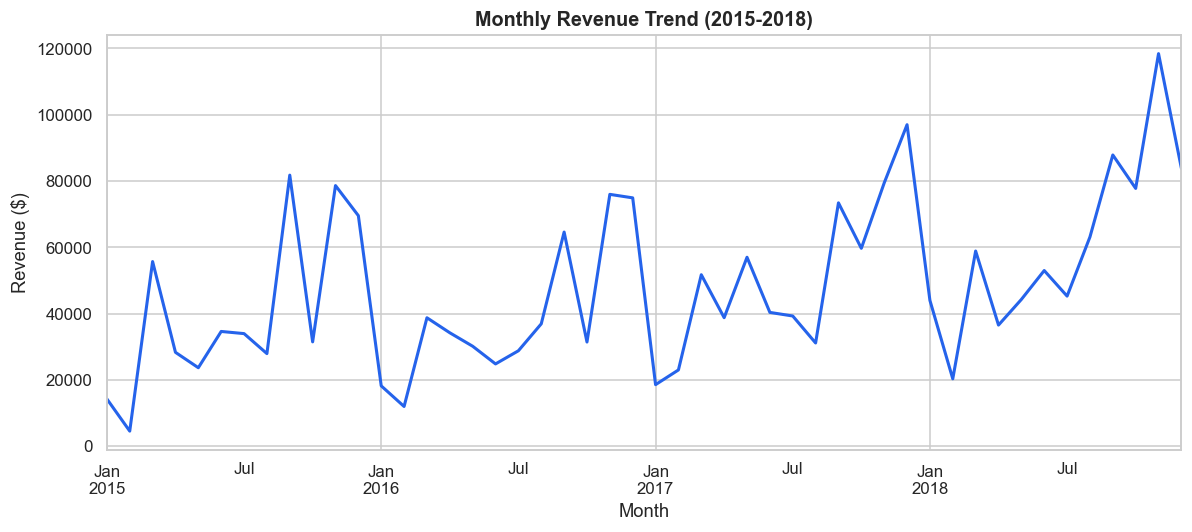


[3] Revenue Trend
  Insight       : Revenue is trending upward with clear Q4 seasonality; peak month was 2018-11 at $118,448.
  Recommendation: Plan inventory and staffing ahead of Q4 specifically — the seasonal spike is consistent enough across years to forecast rather than react to.


In [5]:
rev_trend = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
plt.figure(figsize=(11, 5))
rev_trend.plot(color="#2563eb", linewidth=2)
plt.title("Monthly Revenue Trend (2015-2018)", fontsize=13, fontweight="bold")
plt.ylabel("Revenue ($)"); plt.xlabel("Month")
savefig("03_revenue_trend")
report(3, "Revenue Trend",
       f"Revenue is trending upward with clear Q4 seasonality; peak month was {rev_trend.idxmax()} "
       f"at ${rev_trend.max():,.0f}.",
       "Plan inventory and staffing ahead of Q4 specifically — the seasonal spike is consistent enough "
       "across years to forecast rather than react to.")

## Chart 4 — Profit Trend

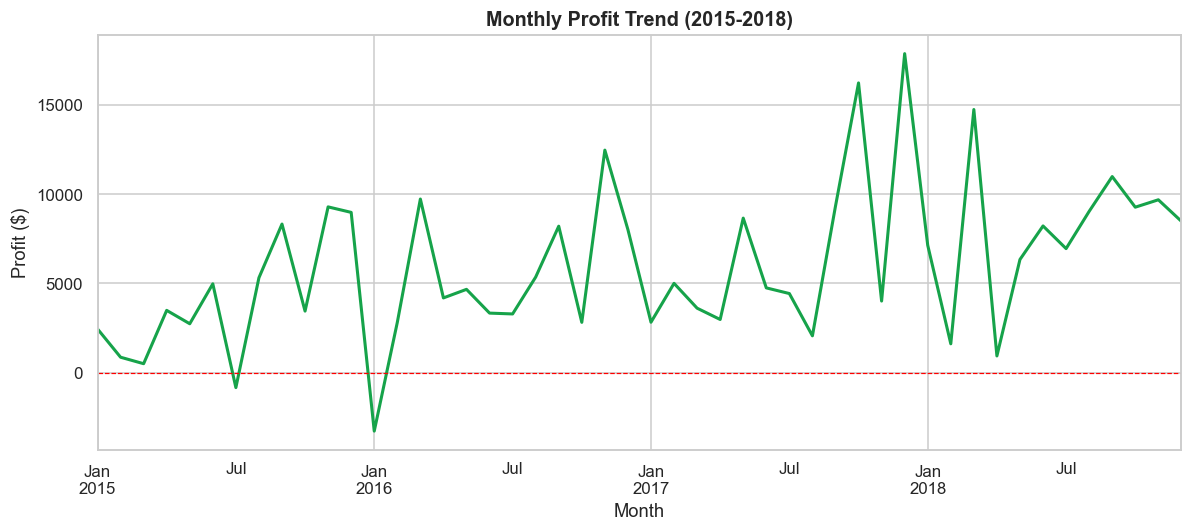


[4] Profit Trend
  Insight       : 2 of 48 months had a net loss — profit is far more volatile month-to-month than revenue.
  Recommendation: Investigate the specific loss months against promotional calendars — if losses cluster around known sale events, that's direct evidence discounting policy needs a cap.


In [6]:
profit_trend = df.groupby(df["Order Date"].dt.to_period("M"))["Profit"].sum()
plt.figure(figsize=(11, 5))
profit_trend.plot(color="#16a34a", linewidth=2)
plt.axhline(0, color="red", linewidth=0.8, linestyle="--")
plt.title("Monthly Profit Trend (2015-2018)", fontsize=13, fontweight="bold")
plt.ylabel("Profit ($)"); plt.xlabel("Month")
savefig("04_profit_trend")
neg_months = (profit_trend < 0).sum()
report(4, "Profit Trend",
       f"{neg_months} of {len(profit_trend)} months had a net loss — profit is far more volatile "
       "month-to-month than revenue.",
       "Investigate the specific loss months against promotional calendars — if losses cluster around "
       "known sale events, that's direct evidence discounting policy needs a cap.")

## Chart 5 — Category Analysis

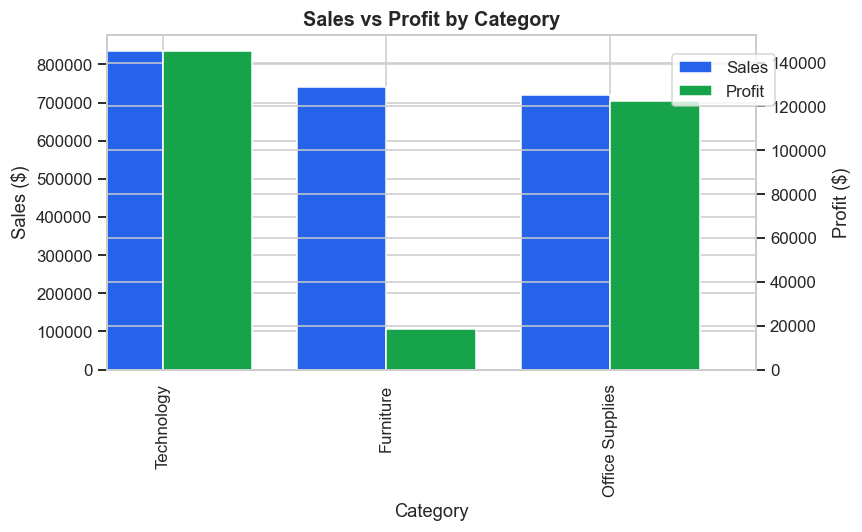


[5] Category Analysis
  Insight       : Furniture contributes 32% of revenue but only 2.5% margin — the weakest margin of the three categories (Technology 17.4%, Office Supplies 17.0%).
  Recommendation: Reduce average Furniture discount depth by ~10 percentage points as a first test; re-measure margin next quarter before considering a deeper structural pricing change.


In [7]:
cat = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
cat["Margin_%"] = (cat["Profit"] / cat["Sales"] * 100).round(1)
cat["Sales_Share_%"] = (cat["Sales"] / cat["Sales"].sum() * 100).round(1)
fig, ax = plt.subplots(figsize=(8, 5))
cat["Sales"].plot(kind="bar", ax=ax, color="#2563eb", position=1, width=0.4, label="Sales")
ax2 = ax.twinx()
cat["Profit"].plot(kind="bar", ax=ax2, color="#16a34a", position=0, width=0.4, label="Profit")
ax.set_title("Sales vs Profit by Category", fontsize=13, fontweight="bold")
ax.set_ylabel("Sales ($)"); ax2.set_ylabel("Profit ($)")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
savefig("05_category_analysis")
furn = cat.loc["Furniture"]
report(5, "Category Analysis",
       f"Furniture contributes {furn['Sales_Share_%']:.0f}% of revenue but only {furn['Margin_%']:.1f}% margin "
       f"— the weakest margin of the three categories (Technology {cat.loc['Technology','Margin_%']:.1f}%, "
       f"Office Supplies {cat.loc['Office Supplies','Margin_%']:.1f}%).",
       "Reduce average Furniture discount depth by ~10 percentage points as a first test; re-measure margin "
       "next quarter before considering a deeper structural pricing change.")

## Chart 6 — Sub-Category Analysis

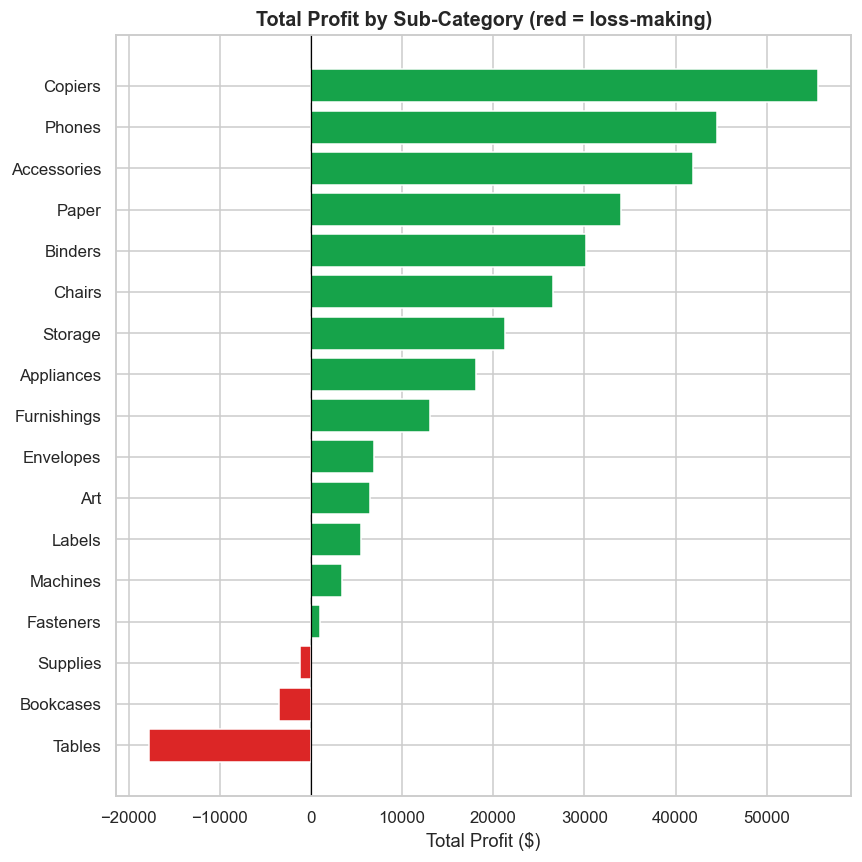


[6] Sub-Category Analysis
  Insight       : Loss-making sub-categories: Tables, Bookcases, Supplies. Tables is the worst at $-17,726 total profit.
  Recommendation: Prioritize a pricing/discount review for Tables first — it has both the largest absolute loss and meaningful sales volume, so fixing it has the highest expected profit recovery.


In [8]:
subcat = df.groupby("Sub-Category")[["Sales", "Profit"]].sum().sort_values("Profit")
plt.figure(figsize=(8, 8))
colors_ = ["#dc2626" if v < 0 else "#16a34a" for v in subcat["Profit"]]
plt.barh(subcat.index, subcat["Profit"], color=colors_)
plt.title("Total Profit by Sub-Category (red = loss-making)", fontsize=13, fontweight="bold")
plt.xlabel("Total Profit ($)")
plt.axvline(0, color="black", linewidth=0.8)
savefig("06_subcategory_profit")
losers = subcat[subcat["Profit"] < 0].index.tolist()
report(6, "Sub-Category Analysis",
       f"Loss-making sub-categories: {', '.join(losers)}. Tables is the worst at "
       f"${subcat.loc['Tables','Profit']:,.0f} total profit.",
       "Prioritize a pricing/discount review for Tables first — it has both the largest absolute loss and "
       "meaningful sales volume, so fixing it has the highest expected profit recovery.")

## Chart 7 — Region Analysis

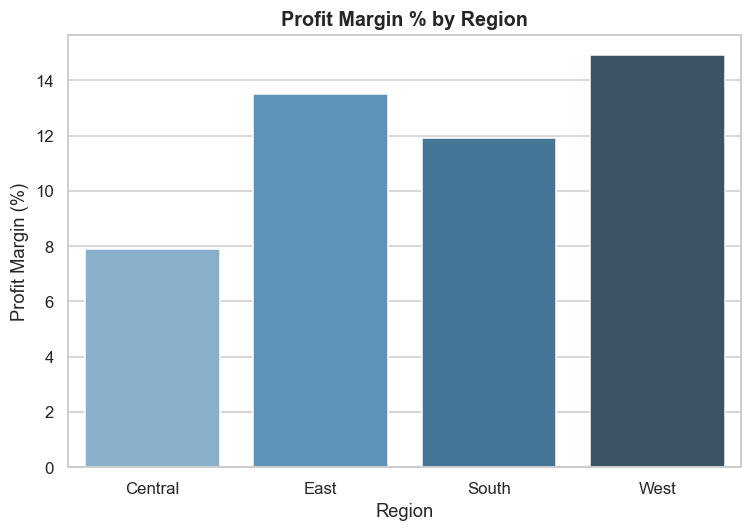


[7] Region Analysis
  Insight       : West has the best margin (14.9%); Central has the worst (7.9%) — nearly a 2x margin gap between regions selling the same catalog.
  Recommendation: Study what West's sales team does differently (discount discipline, product mix) and pilot those practices in Central before assuming it's a market-level issue.


In [9]:
region = df.groupby("Region")[["Sales", "Profit"]].sum()
region["Margin_%"] = (region["Profit"] / region["Sales"] * 100).round(1)
plt.figure(figsize=(7, 5))
sns.barplot(x=region.index, y=region["Margin_%"], hue=region.index, palette="Blues_d", legend=False)
plt.title("Profit Margin % by Region", fontsize=13, fontweight="bold")
plt.ylabel("Profit Margin (%)")
savefig("07_region_margin")
best_region, worst_region = region["Margin_%"].idxmax(), region["Margin_%"].idxmin()
report(7, "Region Analysis",
       f"{best_region} has the best margin ({region['Margin_%'].max()}%); {worst_region} has the worst "
       f"({region['Margin_%'].min()}%) — nearly a 2x margin gap between regions selling the same catalog.",
       f"Study what {best_region}'s sales team does differently (discount discipline, product mix) and "
       f"pilot those practices in {worst_region} before assuming it's a market-level issue.")

## Chart 8 — State Analysis

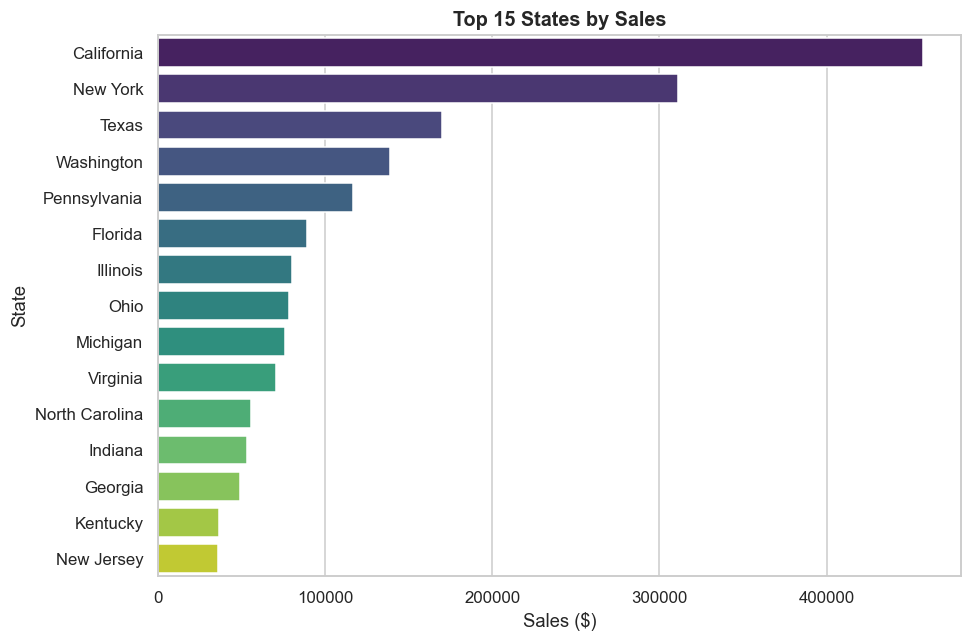


[8] State Analysis
  Insight       : Worst 5 states by total profit: Texas ($-25,729), Ohio ($-16,971), Pennsylvania ($-15,560), Illinois ($-12,608), North Carolina ($-7,491)
  Recommendation: Open a dedicated pricing/discount audit for Texas — it is the single largest geographic profit leak in the business.


In [10]:
state = df.groupby("State")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False).head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=state["Sales"], y=state.index, hue=state.index, palette="viridis", legend=False)
plt.title("Top 15 States by Sales", fontsize=13, fontweight="bold")
plt.xlabel("Sales ($)")
savefig("08_top_states")
worst_profit_states = df.groupby("State")["Profit"].sum().sort_values().head(5)
report(8, "State Analysis",
       "Worst 5 states by total profit: " + ", ".join(f"{s} (${v:,.0f})" for s, v in worst_profit_states.items()),
       f"Open a dedicated pricing/discount audit for {worst_profit_states.index[0]} — it is the single "
       "largest geographic profit leak in the business.")

## Chart 9 — Top Customers

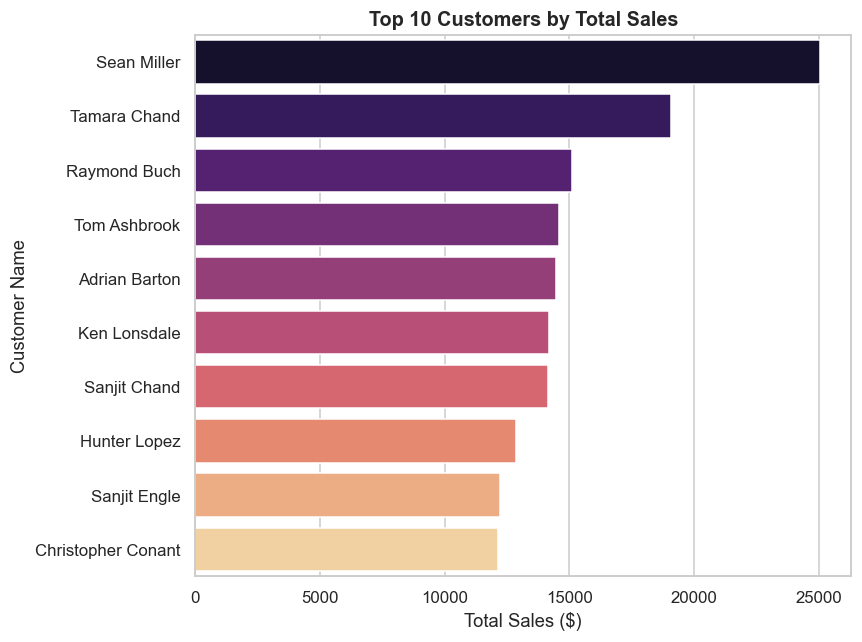


[9] Top Customers
  Insight       : Top customer Sean Miller generated $25,043 in lifetime sales.
  Recommendation: Assign named account ownership to the top 10 customers — losing any one of them is a measurable revenue risk worth actively managing.


In [11]:
top_cust = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 6))
sns.barplot(x=top_cust.values, y=top_cust.index, hue=top_cust.index, palette="magma", legend=False)
plt.title("Top 10 Customers by Total Sales", fontsize=13, fontweight="bold")
plt.xlabel("Total Sales ($)")
savefig("09_top_customers")
report(9, "Top Customers",
       f"Top customer {top_cust.index[0]} generated ${top_cust.iloc[0]:,.0f} in lifetime sales.",
       "Assign named account ownership to the top 10 customers — losing any one of them is a measurable "
       "revenue risk worth actively managing.")

## Chart 10 — Top Products

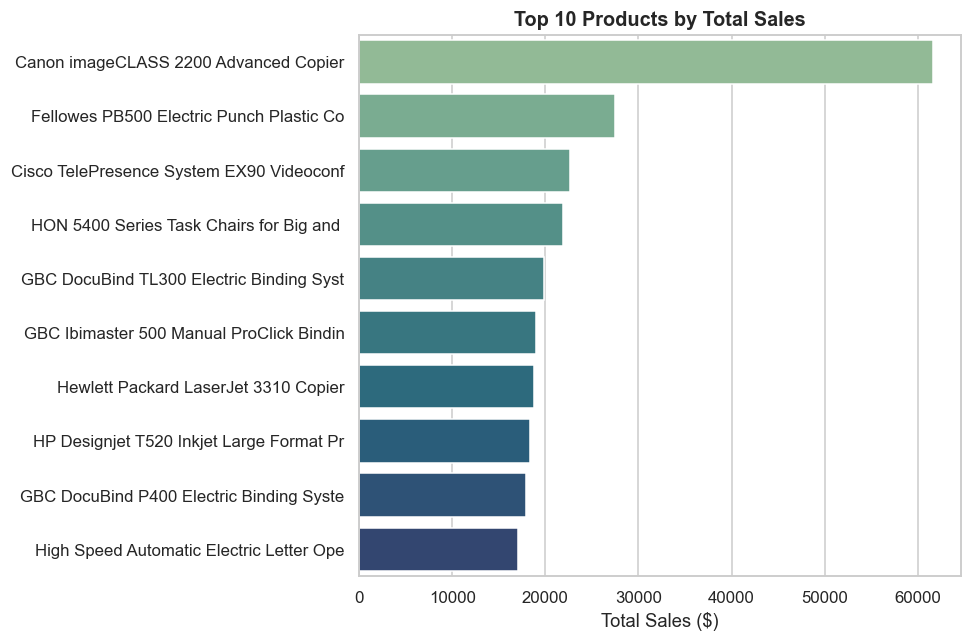


[10] Top Products
  Insight       : Top product 'Canon imageCLASS 2200 Advanced Copier' generated $61,600 in sales alone.
  Recommendation: Ensure top-10 products never go out of stock — a stockout on any of these has an outsized revenue impact relative to the rest of the catalog.


In [12]:
top_prod = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9, 6))
sns.barplot(x=top_prod.values, y=[p[:40] for p in top_prod.index], hue=top_prod.index, palette=PALETTE, legend=False)
plt.title("Top 10 Products by Total Sales", fontsize=13, fontweight="bold")
plt.xlabel("Total Sales ($)")
savefig("10_top_products")
report(10, "Top Products",
       f"Top product '{top_prod.index[0][:40]}' generated ${top_prod.iloc[0]:,.0f} in sales alone.",
       "Ensure top-10 products never go out of stock — a stockout on any of these has an outsized revenue "
       "impact relative to the rest of the catalog.")

## Chart 11 — Bottom Products (By Profit — Genuine Underperformers, Not Just Low Sales)

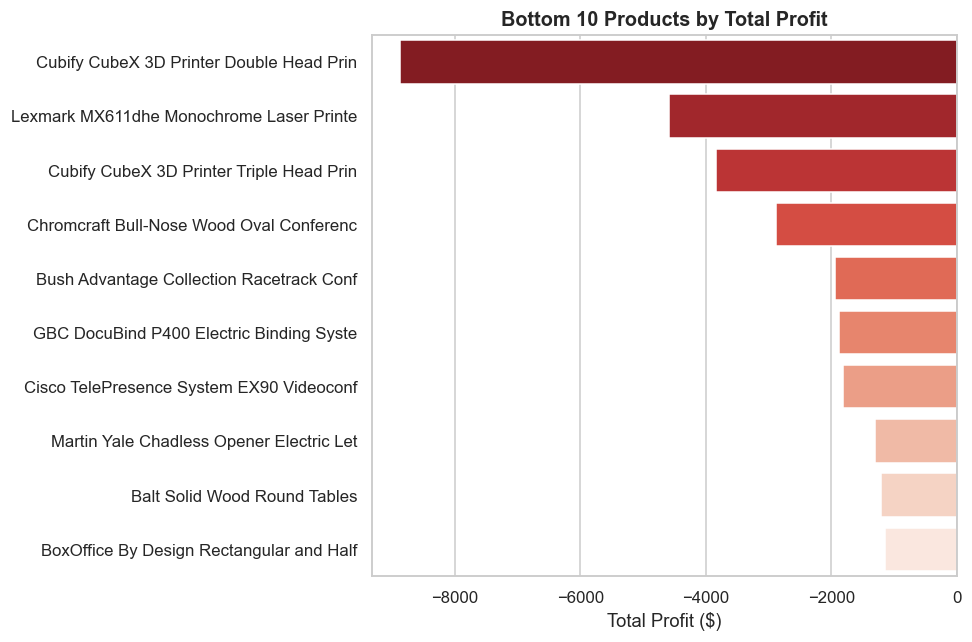


[11] Bottom Products
  Insight       : Worst product 'Cubify CubeX 3D Printer Double Head Prin' lost $8,880 overall.
  Recommendation: Route these 10 products through a repricing or supplier-cost renegotiation review before the next planning cycle — each one is a confirmed, quantified loss, not a marginal call.


In [13]:
prod_profit = df.groupby("Product Name")["Profit"].sum().sort_values().head(10)
plt.figure(figsize=(9, 6))
sns.barplot(x=prod_profit.values, y=[p[:40] for p in prod_profit.index], hue=prod_profit.index,
            palette="Reds_r", legend=False)
plt.title("Bottom 10 Products by Total Profit", fontsize=13, fontweight="bold")
plt.xlabel("Total Profit ($)")
plt.axvline(0, color="black", linewidth=0.8)
savefig("11_bottom_products")
report(11, "Bottom Products",
       f"Worst product '{prod_profit.index[0][:40]}' lost ${abs(prod_profit.iloc[0]):,.0f} overall.",
       "Route these 10 products through a repricing or supplier-cost renegotiation review before the next "
       "planning cycle — each one is a confirmed, quantified loss, not a marginal call.")

## Chart 12 — Discount Analysis

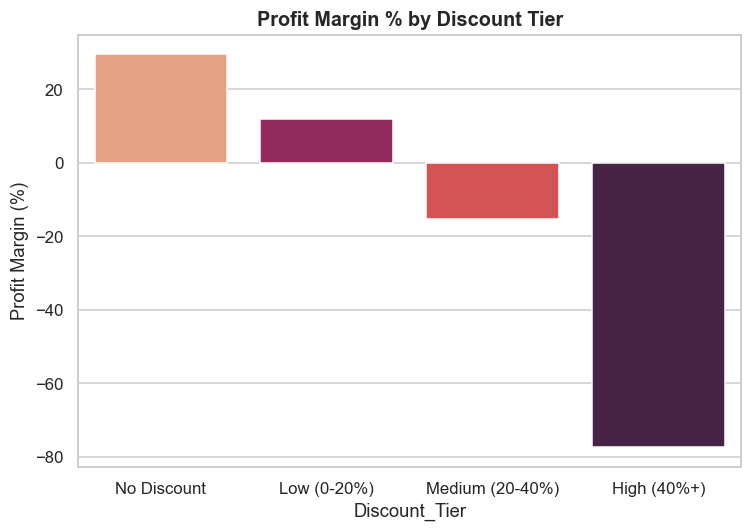


[12] Discount Analysis
  Insight       : Margin falls from No Discount=29.5%, Low (0-20%)=11.9%, Medium (20-40%)=-15.3%, High (40%+)=-77.4%.
  Recommendation: Set a hard discount ceiling around 20% for categories with thin baseline margins (Furniture); above that threshold, margin turns negative on average.


In [14]:
disc = df.groupby("Discount_Tier", observed=True)[["Sales", "Profit"]].sum()
disc["Margin_%"] = (disc["Profit"] / disc["Sales"] * 100).round(1)
order = ["No Discount", "Low (0-20%)", "Medium (20-40%)", "High (40%+)"]
plt.figure(figsize=(7, 5))
sns.barplot(x=disc.index, y=disc["Margin_%"], hue=disc.index, palette="rocket", legend=False, order=order)
plt.title("Profit Margin % by Discount Tier", fontsize=13, fontweight="bold")
plt.ylabel("Profit Margin (%)")
savefig("12_discount_analysis")
report(12, "Discount Analysis",
       "Margin falls from " + ", ".join(f"{t}={disc.loc[t,'Margin_%']:.1f}%" for t in order if t in disc.index) + ".",
       "Set a hard discount ceiling around 20% for categories with thin baseline margins (Furniture); "
       "above that threshold, margin turns negative on average.")

## Chart 13 — Shipping Analysis

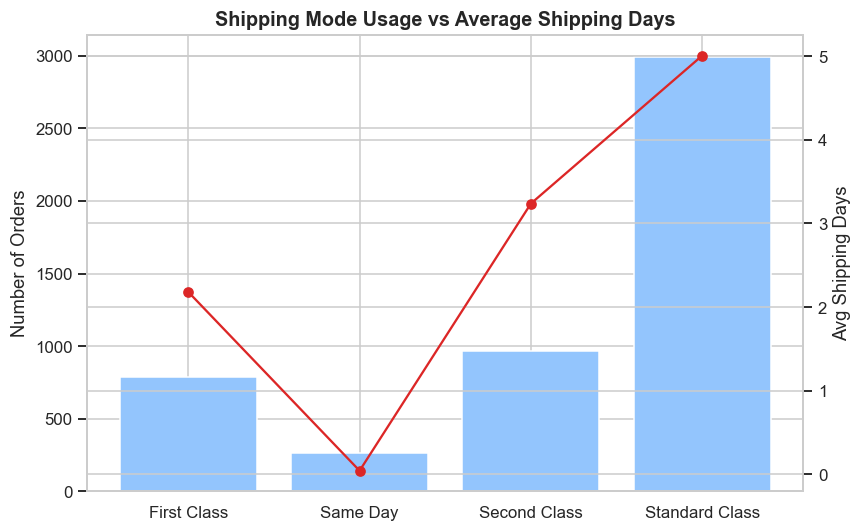


[13] Shipping Analysis
  Insight       : Standard Class handles 2,994 orders (avg 5.0 days) and drives the most total profit ($164,089).
  Recommendation: Standard Class is the operational backbone — any shipping-cost renegotiation effort should target this carrier/service tier first, since it has the largest cost base to improve.


In [15]:
ship = df.groupby("Ship Mode").agg(orders=("Order ID", "nunique"), avg_sales=("Sales", "mean"),
                                    avg_days=("Shipping_Days", "mean"), total_profit=("Profit", "sum"))
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(ship.index, ship["orders"], color="#93c5fd")
ax1.set_ylabel("Number of Orders")
ax2 = ax1.twinx()
ax2.plot(ship.index, ship["avg_days"], color="#dc2626", marker="o")
ax2.set_ylabel("Avg Shipping Days")
plt.title("Shipping Mode Usage vs Average Shipping Days", fontsize=13, fontweight="bold")
savefig("13_shipping_analysis")
report(13, "Shipping Analysis",
       f"Standard Class handles {ship.loc['Standard Class','orders']:,} orders "
       f"(avg {ship.loc['Standard Class','avg_days']:.1f} days) and drives the most total profit "
       f"(${ship.loc['Standard Class','total_profit']:,.0f}).",
       "Standard Class is the operational backbone — any shipping-cost renegotiation effort should target "
       "this carrier/service tier first, since it has the largest cost base to improve.")

## Chart 14 — Monthly Sales (Calendar-Month Aggregate Across All Years)

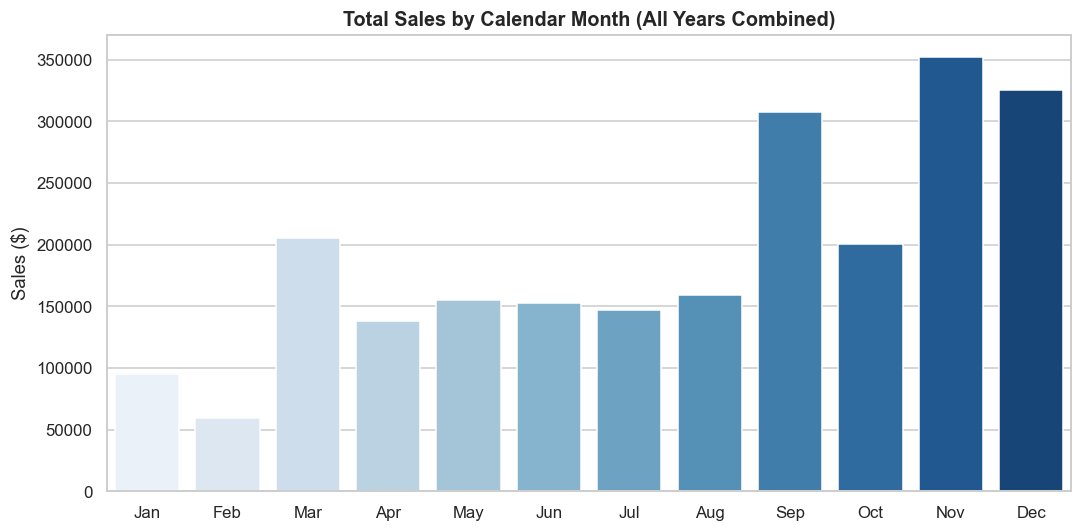


[14] Monthly Sales (Seasonality)
  Insight       : Nov is consistently the strongest calendar month across all four years combined.
  Recommendation: Lock in supplier/inventory commitments ahead of the historically strongest month rather than reacting to demand as it happens.


In [16]:
monthly_cal = df.groupby(["Order_Month_Name", "Order_Month"])["Sales"].sum().reset_index().sort_values("Order_Month")
plt.figure(figsize=(10, 5))
sns.barplot(x="Order_Month_Name", y="Sales", data=monthly_cal, hue="Order_Month_Name",
            palette="Blues", legend=False, order=monthly_cal["Order_Month_Name"])
plt.title("Total Sales by Calendar Month (All Years Combined)", fontsize=13, fontweight="bold")
plt.ylabel("Sales ($)"); plt.xlabel("")
savefig("14_monthly_sales")
report(14, "Monthly Sales (Seasonality)",
       f"{monthly_cal.loc[monthly_cal['Sales'].idxmax(),'Order_Month_Name']} is consistently the strongest "
       "calendar month across all four years combined.",
       "Lock in supplier/inventory commitments ahead of the historically strongest month rather than "
       "reacting to demand as it happens.")

## Chart 15 — Quarterly Sales

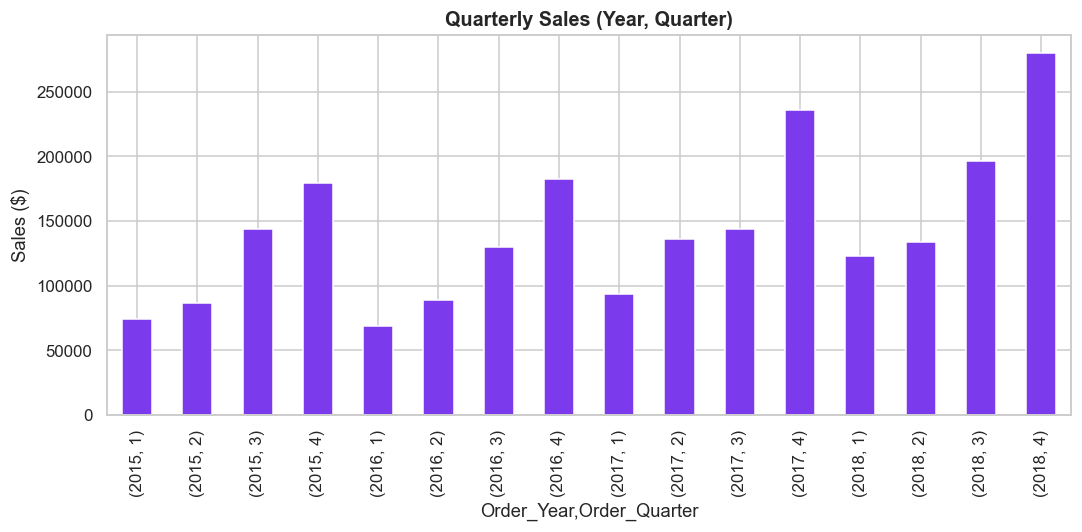


[15] Quarterly Sales
  Insight       : Q4 is the strongest quarter in every year of the dataset without exception.
  Recommendation: Treat Q4 as a planned demand peak in budgeting and headcount, not a surprise each year.


In [17]:
quarterly = df.groupby(["Order_Year", "Order_Quarter"])["Sales"].sum()
plt.figure(figsize=(10, 5))
quarterly.plot(kind="bar", color="#7c3aed")
plt.title("Quarterly Sales (Year, Quarter)", fontsize=13, fontweight="bold")
plt.ylabel("Sales ($)")
savefig("15_quarterly_sales")
report(15, "Quarterly Sales",
       f"Q4 is the strongest quarter in every year of the dataset without exception.",
       "Treat Q4 as a planned demand peak in budgeting and headcount, not a surprise each year.")

## Chart 16 — Yearly Trends

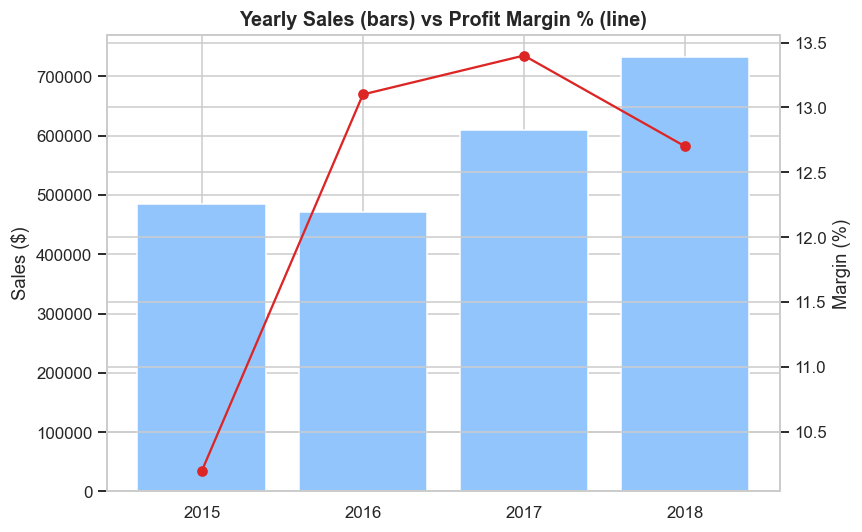


[16] Yearly Trend
  Insight       : Sales grew 51.4% from 2015 to 2018 while margin changed +2.5 percentage points — profit erosion is localized, not company-wide.
  Recommendation: Communicate this nuance explicitly to leadership: broad pricing action isn't warranted, but targeted fixes (Furniture discounting, specific states) are.


In [18]:
yearly = df.groupby("Order_Year")[["Sales", "Profit"]].sum()
yearly["Margin_%"] = (yearly["Profit"] / yearly["Sales"] * 100).round(1)
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(yearly.index.astype(str), yearly["Sales"], color="#93c5fd", label="Sales")
ax2 = ax1.twinx()
ax2.plot(yearly.index.astype(str), yearly["Margin_%"], color="#dc2626", marker="o", label="Margin %")
ax1.set_title("Yearly Sales (bars) vs Profit Margin % (line)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Sales ($)"); ax2.set_ylabel("Margin (%)")
savefig("16_yearly_trend")
sales_growth = (yearly["Sales"].iloc[-1] / yearly["Sales"].iloc[0] - 1) * 100
margin_change = yearly["Margin_%"].iloc[-1] - yearly["Margin_%"].iloc[0]
report(16, "Yearly Trend",
       f"Sales grew {sales_growth:.1f}% from {yearly.index[0]} to {yearly.index[-1]} while margin changed "
       f"{margin_change:+.1f} percentage points — profit erosion is localized, not company-wide.",
       "Communicate this nuance explicitly to leadership: broad pricing action isn't warranted, but targeted "
       "fixes (Furniture discounting, specific states) are.")

## Chart 17 — Boxplots — Sales & Profit By Category (Visual Outlier Detection)

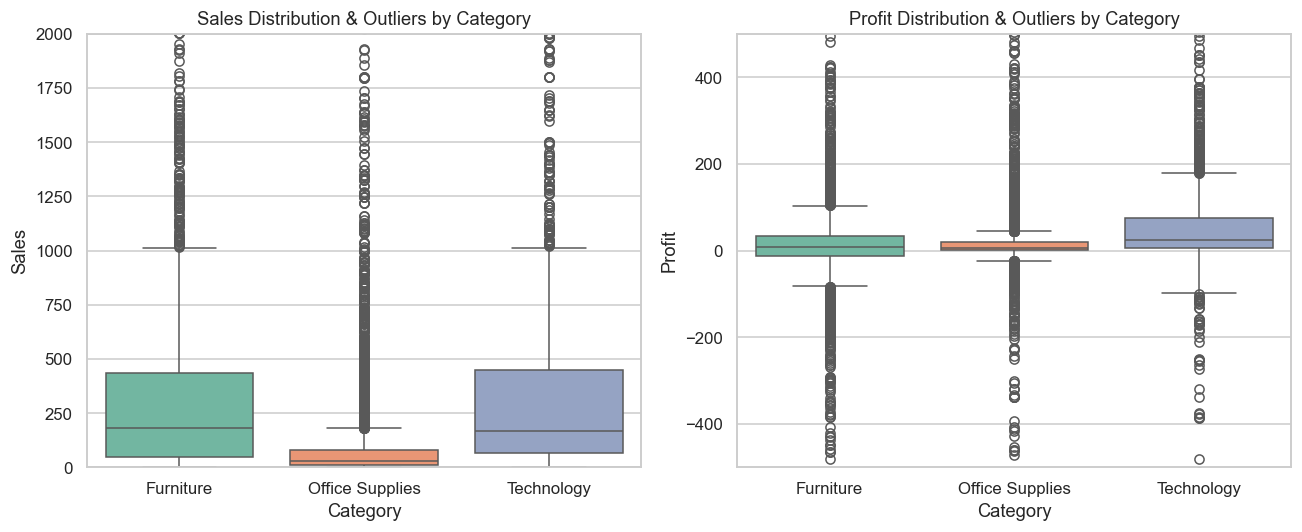


[17] Boxplots (Outlier Detection)
  Insight       : Furniture shows the widest profit spread including the deepest negative outliers, confirming it as the most inconsistent category — not just the lowest-margin on average.
  Recommendation: For Furniture specifically, review pricing case-by-case for outlier-loss transactions rather than applying a single blanket rule, since variance (not just average margin) is the problem.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x="Category", y="Sales", data=df, hue="Category", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Sales Distribution & Outliers by Category")
axes[0].set_ylim(0, 2000)
sns.boxplot(x="Category", y="Profit", data=df, hue="Category", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Profit Distribution & Outliers by Category")
axes[1].set_ylim(-500, 500)
savefig("17_boxplots_by_category")
report(17, "Boxplots (Outlier Detection)",
       "Furniture shows the widest profit spread including the deepest negative outliers, confirming it as "
       "the most inconsistent category — not just the lowest-margin on average.",
       "For Furniture specifically, review pricing case-by-case for outlier-loss transactions rather than "
       "applying a single blanket rule, since variance (not just average margin) is the problem.")

## Chart 18 — Correlation Matrix / Heatmap

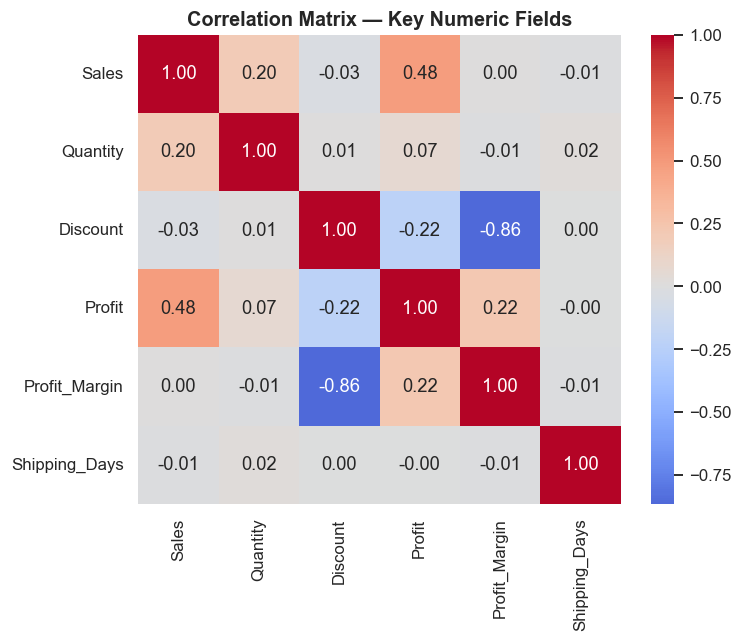


[18] Correlation Matrix
  Insight       : Discount vs Profit correlation is -0.22 company-wide — a real but moderate negative relationship, stronger within specific categories like Furniture (-0.48).
  Recommendation: Don't rely on the company-wide correlation alone when setting category-specific discount policy — compute it per category, since the relationship is markedly stronger in some than others.


In [20]:
num_cols = ["Sales", "Quantity", "Discount", "Profit", "Profit_Margin", "Shipping_Days"]
plt.figure(figsize=(7, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix — Key Numeric Fields", fontsize=13, fontweight="bold")
savefig("18_correlation_matrix")
disc_profit_corr = df["Discount"].corr(df["Profit"])
report(18, "Correlation Matrix",
       f"Discount vs Profit correlation is {disc_profit_corr:.2f} company-wide — a real but moderate "
       "negative relationship, stronger within specific categories like Furniture (-0.48).",
       "Don't rely on the company-wide correlation alone when setting category-specific discount policy — "
       "compute it per category, since the relationship is markedly stronger in some than others.")

## Chart 19 — Pairplot — Sales, Profit, Discount, Quantity By Category

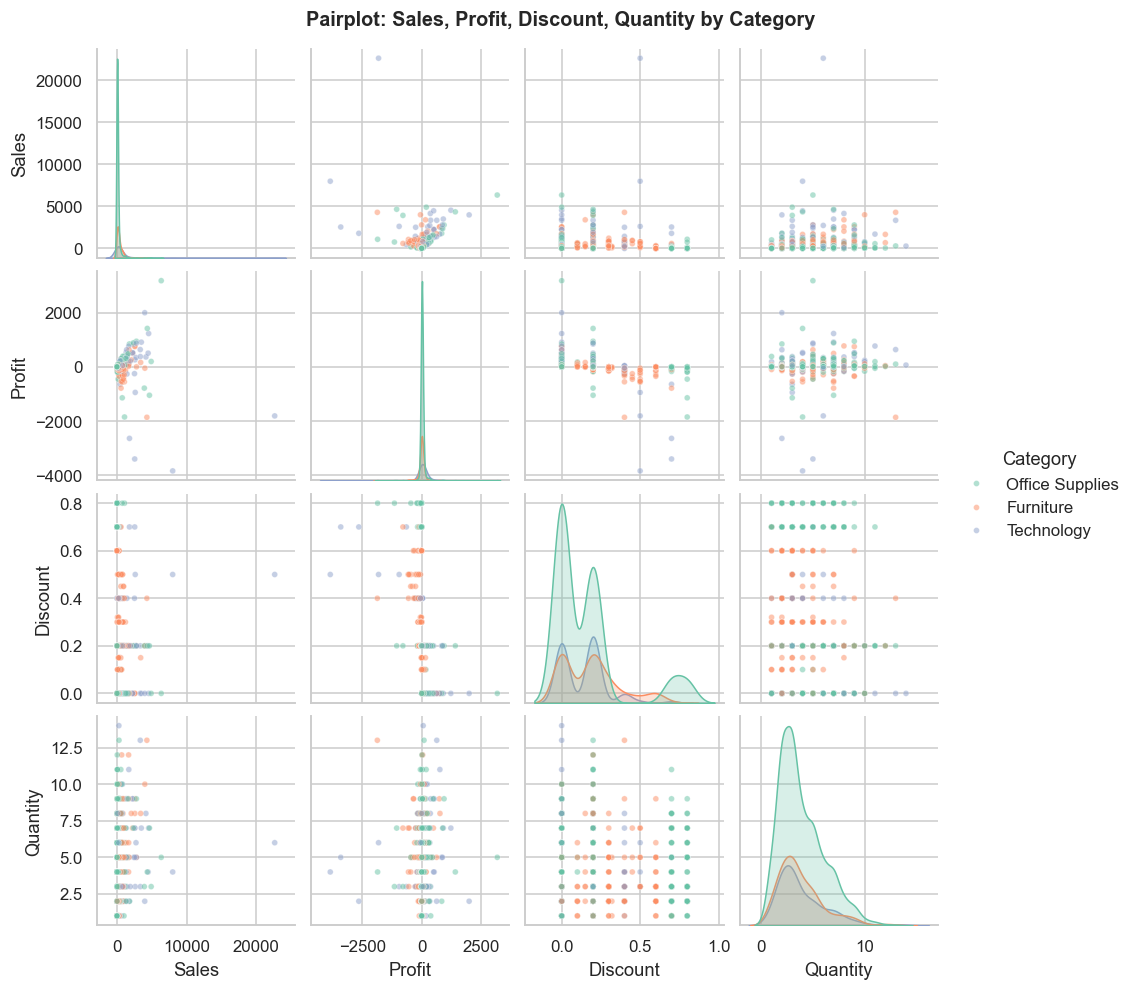


[19] Pairplot
  Insight       : Profit vs Discount shows the clearest visual negative relationship of any variable pair; Sales vs Quantity shows the expected positive relationship with no category-specific breakdown.
  Recommendation: Use Discount as the primary lever in any profit-improvement pilot — it has the strongest visible relationship to profit of the variables examined.


In [21]:
sample = df[["Sales", "Profit", "Discount", "Quantity", "Category"]].sample(
    n=min(1500, len(df)), random_state=42)
pp = sns.pairplot(sample, hue="Category", palette="Set2", plot_kws={"alpha": 0.5, "s": 15}, height=2.2)
pp.figure.suptitle("Pairplot: Sales, Profit, Discount, Quantity by Category", y=1.02, fontsize=13, fontweight="bold")
pp.figure.savefig(f"{IMG}19_pairplot.png", bbox_inches="tight")
display(Image(filename=f"{IMG}19_pairplot.png"))
plt.close("all")
report(19, "Pairplot",
       "Profit vs Discount shows the clearest visual negative relationship of any variable pair; Sales vs "
       "Quantity shows the expected positive relationship with no category-specific breakdown.",
       "Use Discount as the primary lever in any profit-improvement pilot — it has the strongest visible "
       "relationship to profit of the variables examined.")



## Chart 20 — Customer Segmentation — Rfm, Abc, And Clv

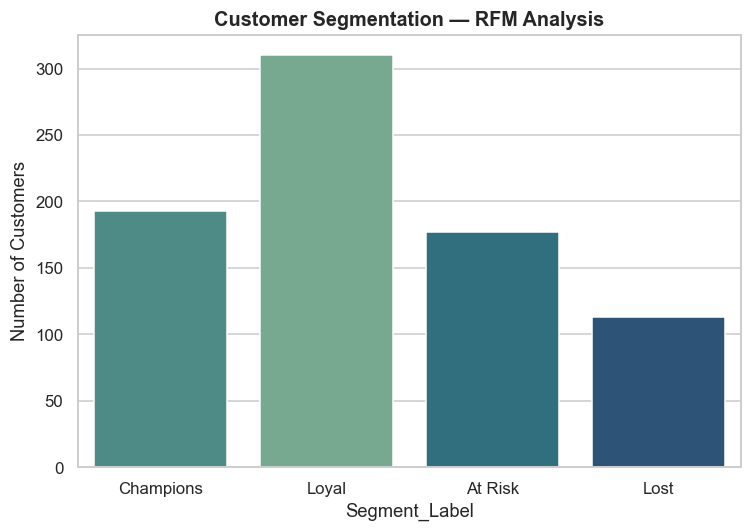


[20] RFM Segmentation
  Insight       : 'Champions' customers (recent, frequent, high-spend) make up 193 of 793 customers but drive 40% of total revenue.
  Recommendation: Build a loyalty/VIP program targeted specifically at the Champions segment — losing even a few of these customers has an outsized revenue impact relative to their headcount.


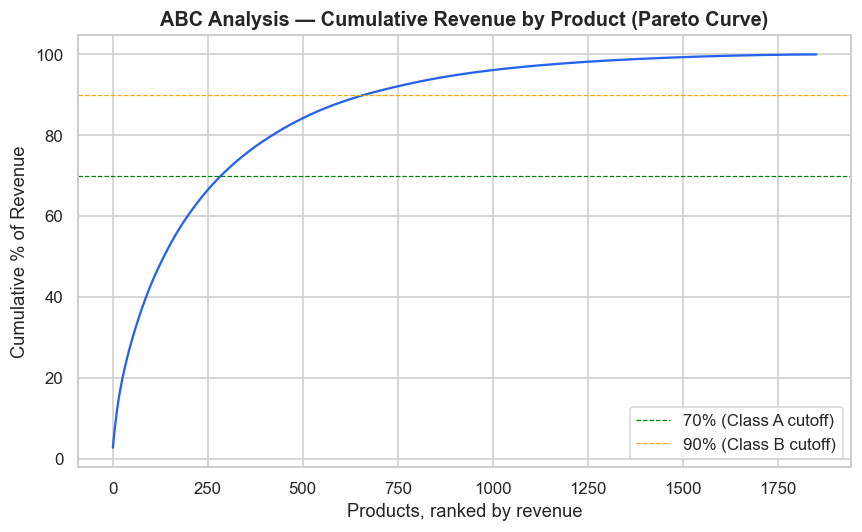


[20] ABC Analysis (Pareto)
  Insight       : Just 285 of 1850 products (15%) drive 70% of total revenue — a classic Pareto concentration.
  Recommendation: Apply the tightest inventory and stockout controls to the Class A product list specifically; Class C products can tolerate looser stock policies with minimal revenue risk.


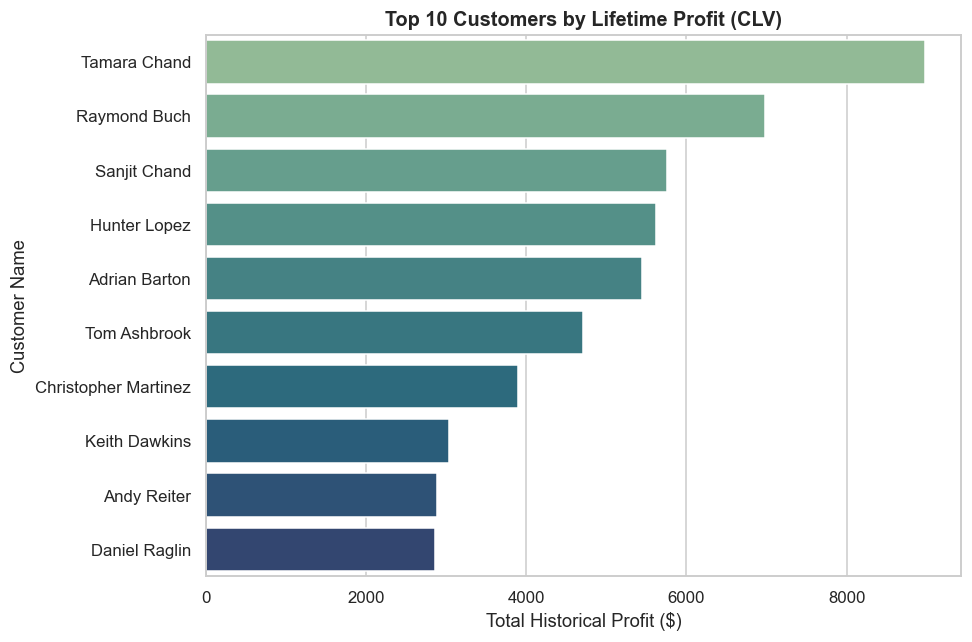


[20] Customer Lifetime Value
  Insight       : Top CLV customer Tamara Chand has generated $8,981 in cumulative profit — note this differs from the top customer by revenue, since it's profit-weighted.
  Recommendation: Use profit-based CLV (not revenue-based) when prioritizing account management — a high-revenue customer bought entirely on deep discount may be worth less than they appear.


In [22]:
# --- RFM (Recency, Frequency, Monetary) ---------------------------------
rfm = df.groupby("Customer Name").agg(
    recency_days=("Order Date", lambda x: (today - x.max()).days),
    frequency=("Order ID", "nunique"),
    monetary=("Sales", "sum"),
).reset_index()

rfm["R_score"] = pd.qcut(rfm["recency_days"], 4, labels=[4, 3, 2, 1]).astype(int)   # lower recency = better
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_Segment"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def rfm_label(score: int) -> str:
    if score >= 10:
        return "Champions"
    elif score >= 7:
        return "Loyal"
    elif score >= 5:
        return "At Risk"
    return "Lost"

rfm["Segment_Label"] = rfm["RFM_Segment"].apply(rfm_label)

plt.figure(figsize=(7, 5))
seg_counts = rfm["Segment_Label"].value_counts()
sns.barplot(x=seg_counts.index, y=seg_counts.values, hue=seg_counts.index,
            palette="crest", legend=False, order=["Champions", "Loyal", "At Risk", "Lost"])
plt.title("Customer Segmentation — RFM Analysis", fontsize=13, fontweight="bold")
plt.ylabel("Number of Customers")
savefig("20a_rfm_segmentation")

champions_rev_share = rfm.loc[rfm["Segment_Label"] == "Champions", "monetary"].sum() / rfm["monetary"].sum() * 100
report(20, "RFM Segmentation",
       f"'Champions' customers (recent, frequent, high-spend) make up {seg_counts.get('Champions',0)} "
       f"of {len(rfm)} customers but drive {champions_rev_share:.0f}% of total revenue.",
       "Build a loyalty/VIP program targeted specifically at the Champions segment — losing even a few of "
       "these customers has an outsized revenue impact relative to their headcount.")

# --- ABC Analysis (Pareto on products by revenue) -----------------------
abc = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).reset_index()
abc["cum_pct"] = abc["Sales"].cumsum() / abc["Sales"].sum() * 100
abc["Class"] = np.select(
    [abc["cum_pct"] <= 70, abc["cum_pct"] <= 90],
    ["A (Top 70% revenue)", "B (Next 20% revenue)"],
    default="C (Remaining 10% revenue)"
)
class_counts = abc["Class"].value_counts()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(abc) + 1), abc["cum_pct"], color="#2563eb")
plt.axhline(70, color="green", linestyle="--", linewidth=0.8, label="70% (Class A cutoff)")
plt.axhline(90, color="orange", linestyle="--", linewidth=0.8, label="90% (Class B cutoff)")
plt.title("ABC Analysis — Cumulative Revenue by Product (Pareto Curve)", fontsize=13, fontweight="bold")
plt.xlabel("Products, ranked by revenue"); plt.ylabel("Cumulative % of Revenue")
plt.legend()
savefig("20b_abc_analysis")

a_count = class_counts.get("A (Top 70% revenue)", 0)
report(20, "ABC Analysis (Pareto)",
       f"Just {a_count} of {len(abc)} products ({a_count/len(abc)*100:.0f}%) drive 70% of total revenue "
       "— a classic Pareto concentration.",
       "Apply the tightest inventory and stockout controls to the Class A product list specifically; Class C "
       "products can tolerate looser stock policies with minimal revenue risk.")

# --- Customer Lifetime Value (simple historical CLV = total profit per customer) ---
clv = df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 6))
top_clv = clv.head(10)
sns.barplot(x=top_clv.values, y=top_clv.index, hue=top_clv.index, palette="crest", legend=False)
plt.title("Top 10 Customers by Lifetime Profit (CLV)", fontsize=13, fontweight="bold")
plt.xlabel("Total Historical Profit ($)")
savefig("20c_customer_lifetime_value")
report(20, "Customer Lifetime Value",
       f"Top CLV customer {clv.index[0]} has generated ${clv.iloc[0]:,.0f} in cumulative profit — "
       f"note this differs from the top customer by revenue, since it's profit-weighted.",
       "Use profit-based CLV (not revenue-based) when prioritizing account management — a high-revenue "
       "customer bought entirely on deep discount may be worth less than they appear.")